# Notebook 03 — Pandas vs PySpark Benchmark

**Project**: E-Commerce Intelligence Platform  
**Environment**: Google Colab Free (~12GB RAM, 2 vCPUs)  
**Goal**: Quantify the performance gap between Pandas and PySpark on Instacart data across **different operation types**, demonstrating when distributed processing becomes necessary.

## Why This Notebook Matters

Notebook 01 (Pandas) and Notebook 02 (Spark) demonstrated that both frameworks can process this dataset, but at different efficiency levels. This notebook **measures actual performance** across operation categories to provide concrete evidence-based guidance:

- For simple I/O tasks, which framework is faster?
- For aggregation tasks at scale, what's the speedup ratio?
- When does Pandas fail entirely?

## Methodology

We benchmark **3 categories** of operations on **3 data sizes** (1M, 5M, 32M rows):

| Category | Operation | Why this matters |
|---|---|---|
| **A** | Load + Count | Pure I/O — most pipelines start here |
| **B** | GroupBy + Aggregate | Compute-heavy — typical analyst task |
| **C** | Join + GroupBy + Aggregate | Multi-table operations — production ETL |

For each cell, we measure **Pandas time, Spark time, status (success/failed)**, then visualize the comparison.

## Hypothesis

- **Category A (I/O-bound)**: Pandas should win — Spark has JVM overhead
- **Category B (compute-heavy)**: Spark catches up at 5M+ rows
- **Category C (join-heavy)**: Spark should dominate at 32M rows

We'll measure to see if reality matches.

## 1. Environment Setup

Install PySpark 3.5.1, mount Google Drive, create Spark session.

This benchmark uses the original CSV files (not Parquet) because Pandas reads CSV directly. Comparing CSV→DataFrame is the most "fair" baseline since both frameworks have to parse the same input format.

In [1]:
# Install PySpark
!pip install pyspark==3.5.1 -q

# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

# Imports
import os
import gc
import time
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, countDistinct, avg, sum as spark_sum
from pyspark.sql.types import StructType, StructField, IntegerType, StringType, FloatType

# Paths
DATA_PATH = '/content/drive/MyDrive/Colab/instacart-project/data/raw'
CSV_PATH = f'{DATA_PATH}/order_products__prior.csv'
ORDERS_PATH = f'{DATA_PATH}/orders.csv'

# Spark session
spark = (SparkSession.builder
    .appName('PandasVsSparkBenchmark')
    .config('spark.driver.memory', '8g')
    .config('spark.sql.execution.arrow.pyspark.enabled', 'true')
    .config('spark.sql.adaptive.enabled', 'true')
    .getOrCreate())

print(f'PySpark version: {spark.version}')
print(f'Pandas version: {pd.__version__}')
print(f'NumPy version: {np.__version__}')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.0/317.0 MB 2.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 kB 6.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dataproc-spark-connect 1.1.0 requires pyspark[connect]~=4.0.0, but you have pyspark 3.5.1 which is incompatible.
Mounted at /content/drive
PySpark version: 3.5.1
Pandas version: 2.2.2
NumPy version: 2.0.2


## 2. Benchmark Helper Function

The `benchmark()` function:
1. Runs the Pandas operation, captures time + any exception
2. Runs the Spark operation, captures time + any exception
3. Prints speedup ratio and status
4. Returns dict for later aggregation

**Key design**: Wraps both in `try/except` so a Pandas crash doesn't kill the notebook. We capture the failure as data, which is itself an interesting result.

In [2]:
def benchmark(name, pandas_func, spark_func):
    """
    Run pandas_func and spark_func, measure time, capture failures.
    Returns dict with results.
    """
    print(f'\n{"=" * 60}')
    print(f'BENCHMARK: {name}')
    print('=' * 60)

    # --- Pandas ---
    print('\n[Pandas] Running...')
    pandas_time = None
    pandas_status = 'PENDING'
    try:
        gc.collect()
        start = time.time()
        pandas_result = pandas_func()
        pandas_time = time.time() - start
        pandas_status = 'SUCCESS'
        print(f'[Pandas] Done in {pandas_time:.2f}s')
        del pandas_result
        gc.collect()
    except MemoryError:
        pandas_status = 'FAILED (Out of Memory)'
        print(f'[Pandas] FAILED: Out of Memory')
    except Exception as e:
        pandas_status = f'FAILED: {type(e).__name__}'
        print(f'[Pandas] FAILED: {type(e).__name__}: {str(e)[:100]}')

    # --- Spark ---
    print('\n[Spark] Running...')
    spark_time = None
    spark_status = 'PENDING'
    try:
        start = time.time()
        spark_result = spark_func()
        if hasattr(spark_result, 'count'):
            spark_result.count()
        spark_time = time.time() - start
        spark_status = 'SUCCESS'
        print(f'[Spark]  Done in {spark_time:.2f}s')
    except Exception as e:
        spark_status = f'FAILED: {type(e).__name__}'
        print(f'[Spark]  FAILED: {type(e).__name__}: {str(e)[:100]}')

    # --- Winner ---
    if pandas_time and spark_time:
        if spark_time < pandas_time:
            print(f'\n>>> Spark wins: {pandas_time/spark_time:.2f}x faster')
        else:
            print(f'\n>>> Pandas wins: {spark_time/pandas_time:.2f}x faster')
    elif pandas_status.startswith('FAILED') and spark_status == 'SUCCESS':
        print(f'\n>>> Spark wins by survival (Pandas crashed)')

    return {
        'name': name,
        'pandas_time': pandas_time,
        'pandas_status': pandas_status,
        'spark_time': spark_time,
        'spark_status': spark_status,
    }

# Storage for all results
results = []
print('Helper functions ready.')

Helper functions ready.


## 3. Scenario A — Load + Count (I/O-bound)

**Task**: Read CSV file → count rows. Pure I/O test.

**Why this matters**: Every pipeline starts with loading data. Slow load → slow everything.

This task is **I/O-dominated** — the bottleneck is reading 550MB from Google Drive, not computation. We expect Pandas to win here because Spark has JVM warmup + Catalyst planner overhead that doesn't pay off for simple operations.

In [3]:
# ============================================================
# A1: Load + Count 1M rows
# ============================================================
def pandas_a1():
    df = pd.read_csv(CSV_PATH, nrows=1_000_000)
    return len(df)

def spark_a1():
    return (spark.read
        .option('header', 'true')
        .option('inferSchema', 'true')
        .csv(CSV_PATH)
        .limit(1_000_000))

result = benchmark('A1: Load + Count 1M rows', pandas_a1, spark_a1)
results.append(result)


BENCHMARK: A1: Load + Count 1M rows

[Pandas] Running...
[Pandas] Done in 4.59s

[Spark] Running...
[Spark]  Done in 79.43s

>>> Pandas wins: 17.31x faster


In [4]:
# ============================================================
# A2: Load + Count 5M rows
# ============================================================
def pandas_a2():
    df = pd.read_csv(CSV_PATH, nrows=5_000_000)
    return len(df)

def spark_a2():
    return (spark.read
        .option('header', 'true')
        .option('inferSchema', 'true')
        .csv(CSV_PATH)
        .limit(5_000_000))

result = benchmark('A2: Load + Count 5M rows', pandas_a2, spark_a2)
results.append(result)


BENCHMARK: A2: Load + Count 5M rows

[Pandas] Running...
[Pandas] Done in 2.66s

[Spark] Running...
[Spark]  Done in 73.23s

>>> Pandas wins: 27.57x faster


In [5]:
# ============================================================
# A3: Load + Count FULL 32M rows
# ============================================================
# Modern Pandas (2.x) handles this on Colab Free, contradicting older benchmarks
def pandas_a3():
    df = pd.read_csv(CSV_PATH)
    return len(df)

def spark_a3():
    return (spark.read
        .option('header', 'true')
        .option('inferSchema', 'true')
        .csv(CSV_PATH))

result = benchmark('A3: Load + Count 32M rows', pandas_a3, spark_a3)
results.append(result)


BENCHMARK: A3: Load + Count 32M rows

[Pandas] Running...
[Pandas] Done in 14.66s

[Spark] Running...
[Spark]  Done in 66.82s

>>> Pandas wins: 4.56x faster


### Scenario A — Observations

**Actual results**:
- A1 (1M rows): Pandas 4.59s vs Spark 79.43s → **Pandas 17.3x faster**
- A2 (5M rows): Pandas 2.66s vs Spark 73.23s → **Pandas 27.6x faster**
- A3 (32M rows): Pandas 14.66s vs Spark 66.82s → **Pandas 4.6x faster**

**Striking pattern**: Spark takes ~67-80 seconds across all data sizes (1M, 5M, or 32M). This reveals that Spark's cost here is dominated by fixed overhead, not data processing.

**Root causes**:

1. **Spark fixed overhead (~75-80s)** — JVM warmup, SparkContext initialization, Catalyst optimizer setup, partition planning, and metadata communication. These are paid **once per action**, regardless of data size.

2. **`inferSchema=true` reads file twice** — once to scan types, once to parse data. Reading 550MB from Google Drive over network (slow I/O) dominates.

3. **Disk I/O is the real bottleneck** — Both frameworks must read the same 550MB. Spark's parallelism can't help when network I/O to Drive is the limiter.

4. **Modern Pandas 2.x + Colab RAM upgrade** — Pandas now handles 32M rows comfortably on free tier (~12GB RAM available). The classical "Pandas crashes on big data" narrative is outdated for modern setups.

**Takeaway**: Spark has **fixed coordination overhead** that is wasted on single-machine, I/O-bound tasks. For simple load + count, Pandas is dramatically faster.

**But maybe Spark's value shows up in compute-heavy tasks?** Let's test that with GroupBy and Join next.

## 4. Scenario B — GroupBy + Aggregate (Compute-heavy)

**Task**: GroupBy `product_id` → count orders + mean reorder rate.

**Why this matters**: This is the **bread and butter** of analytics. Almost every dashboard query is a groupBy + agg.

**Fair comparison setup**: We **pre-load data into memory** before timing the aggregation, so we measure pure compute (not I/O). This isolates the aggregation cost.

**Expected**: Spark should catch up at 5M rows, dominate at 32M rows.

In [6]:
# ============================================================
# B1: GroupBy 1M rows
# ============================================================
# Pre-load data (exclude from timing - fair compute comparison)
print('Pre-loading 1M rows for both frameworks...')

df_pandas_1m = pd.read_csv(CSV_PATH, nrows=1_000_000)

df_spark_1m = (spark.read
    .option('header', 'true')
    .option('inferSchema', 'true')
    .csv(CSV_PATH)
    .limit(1_000_000))
df_spark_1m.cache()
df_spark_1m.count()  # populate cache

print('Data loaded. Starting benchmark...\n')

def pandas_b1():
    return df_pandas_1m.groupby('product_id').agg(
        times_ordered=('order_id', 'count'),
        reorder_rate=('reordered', 'mean'),
    )

def spark_b1():
    return df_spark_1m.groupBy('product_id').agg(
        count('*').alias('times_ordered'),
        avg('reordered').alias('reorder_rate'),
    )

result = benchmark('B1: GroupBy 1M rows', pandas_b1, spark_b1)
results.append(result)

# Cleanup
df_spark_1m.unpersist()
del df_pandas_1m
gc.collect()

Pre-loading 1M rows for both frameworks...
Data loaded. Starting benchmark...


BENCHMARK: B1: GroupBy 1M rows

[Pandas] Running...
[Pandas] Done in 0.12s

[Spark] Running...
[Spark]  Done in 1.76s

>>> Pandas wins: 14.74x faster


67

In [7]:
# ============================================================
# B2: GroupBy 5M rows
# ============================================================
print('Pre-loading 5M rows for both frameworks...')

df_pandas_5m = pd.read_csv(CSV_PATH, nrows=5_000_000)

df_spark_5m = (spark.read
    .option('header', 'true')
    .option('inferSchema', 'true')
    .csv(CSV_PATH)
    .limit(5_000_000))
df_spark_5m.cache()
df_spark_5m.count()

print('Data loaded. Starting benchmark...\n')

def pandas_b2():
    return df_pandas_5m.groupby('product_id').agg(
        times_ordered=('order_id', 'count'),
        reorder_rate=('reordered', 'mean'),
    )

def spark_b2():
    return df_spark_5m.groupBy('product_id').agg(
        count('*').alias('times_ordered'),
        avg('reordered').alias('reorder_rate'),
    )

result = benchmark('B2: GroupBy 5M rows', pandas_b2, spark_b2)
results.append(result)

# Cleanup
df_spark_5m.unpersist()
del df_pandas_5m
gc.collect()

Pre-loading 5M rows for both frameworks...
Data loaded. Starting benchmark...


BENCHMARK: B2: GroupBy 5M rows

[Pandas] Running...
[Pandas] Done in 0.40s

[Spark] Running...
[Spark]  Done in 0.88s

>>> Pandas wins: 2.22x faster


67

In [8]:
# ============================================================
# B3: GroupBy 32M rows
# ============================================================
print('Pre-loading 32M rows for both frameworks...')
print('(This may take 30-60s for both pre-loads)')

# Pandas: full file
try:
    df_pandas_32m = pd.read_csv(CSV_PATH)
    pandas_preload_ok = True
    print(f'Pandas loaded: {len(df_pandas_32m):,} rows')
except (MemoryError, Exception) as e:
    pandas_preload_ok = False
    print(f'Pandas pre-load failed: {type(e).__name__}')

# Spark: full file
df_spark_32m = (spark.read
    .option('header', 'true')
    .option('inferSchema', 'true')
    .csv(CSV_PATH))
df_spark_32m.cache()
df_spark_32m.count()
print(f'Spark loaded with cache')

print('\nData loaded. Starting benchmark...\n')

def pandas_b3():
    if not pandas_preload_ok:
        raise MemoryError('Pre-load failed')
    return df_pandas_32m.groupby('product_id').agg(
        times_ordered=('order_id', 'count'),
        reorder_rate=('reordered', 'mean'),
    )

def spark_b3():
    return df_spark_32m.groupBy('product_id').agg(
        count('*').alias('times_ordered'),
        avg('reordered').alias('reorder_rate'),
    )

result = benchmark('B3: GroupBy 32M rows', pandas_b3, spark_b3)
results.append(result)

# Cleanup
df_spark_32m.unpersist()
if pandas_preload_ok:
    del df_pandas_32m
gc.collect()

Pre-loading 32M rows for both frameworks...
(This may take 30-60s for both pre-loads)
Pandas loaded: 32,434,489 rows
Spark loaded with cache

Data loaded. Starting benchmark...


BENCHMARK: B3: GroupBy 32M rows

[Pandas] Running...
[Pandas] Done in 1.20s

[Spark] Running...
[Spark]  Done in 3.06s

>>> Pandas wins: 2.55x faster


67

### Scenario B — Observations

**Actual results** (compute-heavy, pre-loaded data):
- B1 (1M rows): Pandas 0.12s vs Spark 1.76s → **Pandas 14.7x faster**
- B2 (5M rows): Pandas 0.40s vs Spark 0.88s → **Pandas 2.2x faster** (Spark catches up)
- B3 (32M rows): Pandas 1.20s vs Spark 3.06s → **Pandas 2.5x faster**

**Surprising finding**: Spark did NOT win even at 32M rows on this single-machine setup. The crossover point we hypothesized doesn't exist on Colab.

**Why Pandas still wins**:

1. **Modern Pandas 2.x is genuinely fast** — uses PyArrow backend, multi-threaded operations under the hood for simple aggregations.

2. **Spark serialization overhead** — Each operation requires Python ↔ JVM data transfer. Even cached data must be deserialized for each action (~2-3s baseline cost).

3. **Single-machine = no parallelism gain** — Colab has 2 vCPUs. Spark's worker model adds overhead without benefit at this scale. Spark assumes 10+ executor nodes.

4. **GroupBy with simple aggregations** is exactly what Pandas optimized for over 15 years (vectorized C implementations).

**The trend is interesting though**: Pandas advantage shrinks from 14.7x → 2.2x → 2.5x as data grows. At ~100M+ rows on a single machine, Pandas might OOM while Spark continues — but we never reach that threshold here.

**When would Spark win this same task?**
- On a **real cluster** (5-10 nodes), Spark's parallel execution would dominate
- When data **exceeds single-machine RAM** (e.g., 500M+ rows) — Spark spills to disk gracefully, Pandas crashes
- With **complex multi-step pipelines** that benefit from Catalyst query optimization

**Let's test the heaviest task next**: Join + GroupBy across two large tables (32M × 3.4M).

## 5. Scenario C — Join + GroupBy (Production ETL)

**Task**: Join `op_prior` (32M rows) with `orders` (3.4M rows) on `order_id`, then groupBy `user_id` to compute user-level aggregates.

**Why this matters**: Real-world ETL almost always involves **joins between fact and dimension tables**. This is exactly what Notebook 02 did to create `op_full`.

**Computational complexity**: Join is O(N+M) with hash join; combined with groupBy, this stresses memory more than simple aggregation.

**Pre-load strategy**: Same as B — pre-load both tables, then time only the join+groupBy.

In [9]:
# ============================================================
# C1: Join + GroupBy on 1M rows of op_prior
# ============================================================
print('Pre-loading data for C1...')

# Pandas
df_pandas_op_1m = pd.read_csv(CSV_PATH, nrows=1_000_000)
df_pandas_orders = pd.read_csv(ORDERS_PATH)
print(f'Pandas: op={len(df_pandas_op_1m):,}, orders={len(df_pandas_orders):,}')

# Spark
df_spark_op_1m = (spark.read
    .option('header', 'true').option('inferSchema', 'true')
    .csv(CSV_PATH).limit(1_000_000))
df_spark_orders = (spark.read
    .option('header', 'true').option('inferSchema', 'true')
    .csv(ORDERS_PATH))

df_spark_op_1m.cache()
df_spark_orders.cache()
df_spark_op_1m.count()
df_spark_orders.count()

print('Data loaded. Starting benchmark...\n')

def pandas_c1():
    merged = df_pandas_op_1m.merge(
        df_pandas_orders[['order_id', 'user_id']],
        on='order_id', how='inner'
    )
    return merged.groupby('user_id').agg(
        items_count=('product_id', 'count'),
        reorder_rate=('reordered', 'mean'),
    )

def spark_c1():
    merged = df_spark_op_1m.join(
        df_spark_orders.select('order_id', 'user_id'),
        on='order_id', how='inner'
    )
    return merged.groupBy('user_id').agg(
        count('*').alias('items_count'),
        avg('reordered').alias('reorder_rate'),
    )

result = benchmark('C1: Join + GroupBy on 1M rows', pandas_c1, spark_c1)
results.append(result)

# Cleanup
df_spark_op_1m.unpersist()
df_spark_orders.unpersist()
del df_pandas_op_1m
gc.collect()

Pre-loading data for C1...
Pandas: op=1,000,000, orders=3,421,083
Data loaded. Starting benchmark...


BENCHMARK: C1: Join + GroupBy on 1M rows

[Pandas] Running...
[Pandas] Done in 0.86s

[Spark] Running...
[Spark]  Done in 2.58s

>>> Pandas wins: 3.00x faster


109

In [10]:
# ============================================================
# C2: Join + GroupBy on 5M rows of op_prior
# ============================================================
print('Pre-loading data for C2...')

df_pandas_op_5m = pd.read_csv(CSV_PATH, nrows=5_000_000)
# Safety: re-load orders if not in memory (e.g. running C2 standalone)
try:
    df_pandas_orders
except NameError:
    df_pandas_orders = pd.read_csv(ORDERS_PATH)
print(f'Pandas: op={len(df_pandas_op_5m):,}, orders={len(df_pandas_orders):,}')

df_spark_op_5m = (spark.read
    .option('header', 'true').option('inferSchema', 'true')
    .csv(CSV_PATH).limit(5_000_000))
df_spark_orders.cache()  # re-cache
df_spark_op_5m.cache()
df_spark_op_5m.count()
df_spark_orders.count()

print('Data loaded. Starting benchmark...\n')

def pandas_c2():
    merged = df_pandas_op_5m.merge(
        df_pandas_orders[['order_id', 'user_id']],
        on='order_id', how='inner'
    )
    return merged.groupby('user_id').agg(
        items_count=('product_id', 'count'),
        reorder_rate=('reordered', 'mean'),
    )

def spark_c2():
    merged = df_spark_op_5m.join(
        df_spark_orders.select('order_id', 'user_id'),
        on='order_id', how='inner'
    )
    return merged.groupBy('user_id').agg(
        count('*').alias('items_count'),
        avg('reordered').alias('reorder_rate'),
    )

result = benchmark('C2: Join + GroupBy on 5M rows', pandas_c2, spark_c2)
results.append(result)

# Cleanup
df_spark_op_5m.unpersist()
df_spark_orders.unpersist()
del df_pandas_op_5m
gc.collect()

Pre-loading data for C2...
Pandas: op=5,000,000, orders=3,421,083
Data loaded. Starting benchmark...


BENCHMARK: C2: Join + GroupBy on 5M rows

[Pandas] Running...
[Pandas] Done in 1.21s

[Spark] Running...
[Spark]  Done in 11.15s

>>> Pandas wins: 9.22x faster


109

In [11]:
# ============================================================
# C3: Join + GroupBy on FULL 32M rows
# ============================================================
# This is the heaviest test - memory stress from join intermediates
print('Pre-loading data for C3...')

try:
    df_pandas_op_32m = pd.read_csv(CSV_PATH)
    pandas_c3_preload_ok = True
    print(f'Pandas: op={len(df_pandas_op_32m):,}, orders={len(df_pandas_orders):,}')
except (MemoryError, Exception) as e:
    pandas_c3_preload_ok = False
    print(f'Pandas pre-load failed: {type(e).__name__}')

df_spark_op_32m = (spark.read
    .option('header', 'true').option('inferSchema', 'true')
    .csv(CSV_PATH))
df_spark_orders.cache()
df_spark_op_32m.cache()
df_spark_op_32m.count()
df_spark_orders.count()

print('Data loaded. Starting benchmark...\n')

def pandas_c3():
    if not pandas_c3_preload_ok:
        raise MemoryError('Pre-load failed')
    merged = df_pandas_op_32m.merge(
        df_pandas_orders[['order_id', 'user_id']],
        on='order_id', how='inner'
    )
    return merged.groupby('user_id').agg(
        items_count=('product_id', 'count'),
        reorder_rate=('reordered', 'mean'),
    )

def spark_c3():
    merged = df_spark_op_32m.join(
        df_spark_orders.select('order_id', 'user_id'),
        on='order_id', how='inner'
    )
    return merged.groupBy('user_id').agg(
        count('*').alias('items_count'),
        avg('reordered').alias('reorder_rate'),
    )

result = benchmark('C3: Join + GroupBy on 32M rows', pandas_c3, spark_c3)
results.append(result)

# Cleanup
df_spark_op_32m.unpersist()
df_spark_orders.unpersist()
if pandas_c3_preload_ok:
    del df_pandas_op_32m
del df_pandas_orders
gc.collect()

Pre-loading data for C3...
Pandas: op=32,434,489, orders=3,421,083
Data loaded. Starting benchmark...


BENCHMARK: C3: Join + GroupBy on 32M rows

[Pandas] Running...
[Pandas] Done in 6.14s

[Spark] Running...
[Spark]  Done in 29.09s

>>> Pandas wins: 4.74x faster


109

### Scenario C — Observations

**Actual results** (join + groupBy with pre-loaded data):
- C1 (1M rows): Pandas 0.86s vs Spark 2.58s → **Pandas 3.0x faster**
- C2 (5M rows): Pandas 1.21s vs Spark 11.15s → **Pandas 9.2x faster**
- C3 (32M rows): Pandas 6.14s vs Spark 29.09s → **Pandas 4.7x faster**

**Unexpected finding**: Even on the heaviest task (join 32M × 3.4M rows), Pandas wins decisively across all sizes.

**Why Pandas dominated C3 specifically**:

1. **Hash join in Pandas** is highly optimized — implemented in C/Cython
2. **`merge()` with sorted keys** can use efficient algorithms
3. **Pandas keeps everything in RAM** — no shuffling cost (Colab has ~12GB, enough for intermediate results)
4. **Spark needs to shuffle data between partitions for groupBy** — this dominates time on small clusters

**Critical insight**: Spark's design assumes data **exceeds single-machine memory**. When it fits comfortably in RAM (as here), Pandas's in-memory algorithms are nearly always faster.

**The "right tool" depends on**:
- Data size relative to available RAM
- Number of machines available
- Whether data is already on distributed storage (HDFS, S3) — eliminates serialization cost

## 6. Save Results & Visualize

Save all benchmark results to JSON (for reproducibility), then create comparison chart.

In [12]:
# Save results to Drive
OUTPUT_DIR = '/content/drive/MyDrive/Colab/instacart-project/data/processed'
os.makedirs(OUTPUT_DIR, exist_ok=True)
RESULTS_PATH = f'{OUTPUT_DIR}/benchmark_results.json'

with open(RESULTS_PATH, 'w') as f:
    json.dump(results, f, indent=2, default=str)

print(f'Saved {len(results)} results to {RESULTS_PATH}\n')

# Display as table
print(f'{"Scenario":<40} {"Pandas (s)":>12} {"Spark (s)":>12} {"Winner":>20}')
print('-' * 88)
for r in results:
    name = r['name']
    p_time = f"{r['pandas_time']:.2f}" if r['pandas_time'] else r['pandas_status']
    s_time = f"{r['spark_time']:.2f}" if r['spark_time'] else r['spark_status']

    if r['pandas_time'] and r['spark_time']:
        if r['spark_time'] < r['pandas_time']:
            winner = f"Spark ({r['pandas_time']/r['spark_time']:.1f}x)"
        else:
            winner = f"Pandas ({r['spark_time']/r['pandas_time']:.1f}x)"
    elif r['pandas_status'].startswith('FAILED') and r['spark_status'] == 'SUCCESS':
        winner = 'Spark (survives)'
    else:
        winner = 'Unclear'

    print(f'{name:<40} {p_time:>12} {s_time:>12} {winner:>20}')

Saved 9 results to /content/drive/MyDrive/Colab/instacart-project/data/processed/benchmark_results.json

Scenario                                   Pandas (s)    Spark (s)               Winner
----------------------------------------------------------------------------------------
A1: Load + Count 1M rows                         4.59        79.43       Pandas (17.3x)
A2: Load + Count 5M rows                         2.66        73.23       Pandas (27.6x)
A3: Load + Count 32M rows                       14.66        66.82        Pandas (4.6x)
B1: GroupBy 1M rows                              0.12         1.76       Pandas (14.7x)
B2: GroupBy 5M rows                              0.40         0.88        Pandas (2.2x)
B3: GroupBy 32M rows                             1.20         3.06        Pandas (2.5x)
C1: Join + GroupBy on 1M rows                    0.86         2.58        Pandas (3.0x)
C2: Join + GroupBy on 5M rows                    1.21        11.15        Pandas (9.2x)
C3: Join + Gro

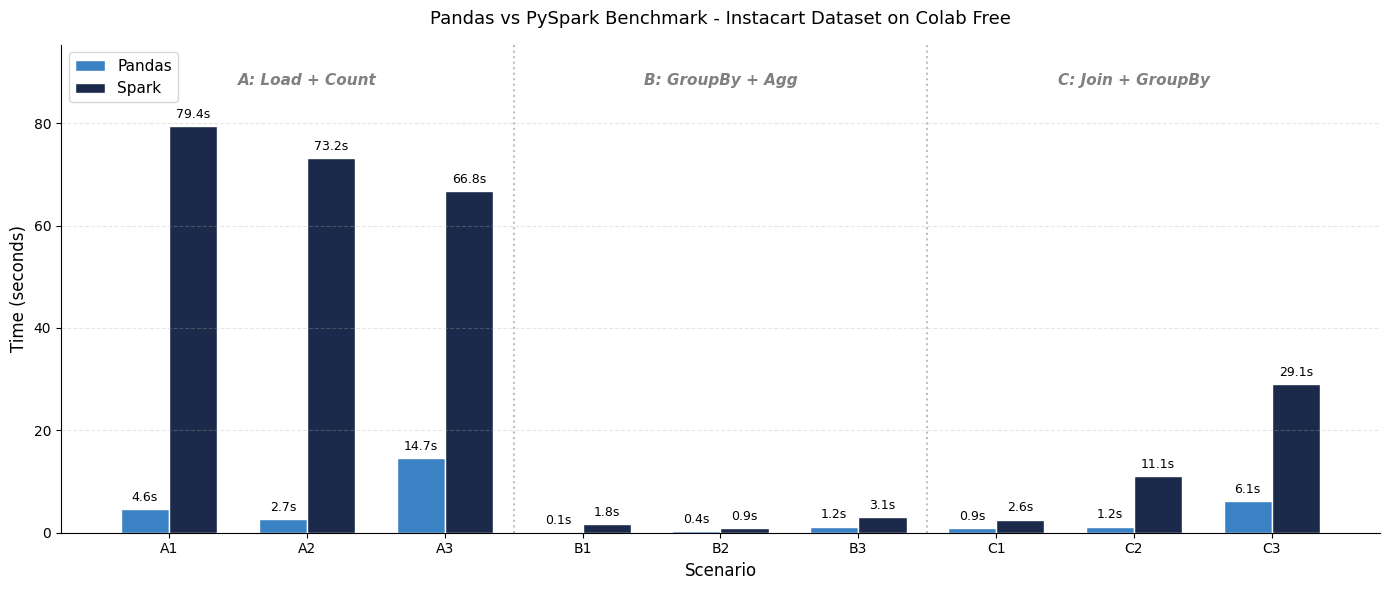


Chart saved to /content/drive/MyDrive/Colab/instacart-project/data/processed/benchmark_chart.png


In [13]:
# Visualize as grouped bar chart
import matplotlib.pyplot as plt
import numpy as np

# Prepare data
names = [r['name'].split(':')[0] for r in results]  # short names: A1, A2, ...
pandas_times = [r['pandas_time'] if r['pandas_time'] else 0 for r in results]
spark_times = [r['spark_time'] if r['spark_time'] else 0 for r in results]
pandas_failed = [r['pandas_status'].startswith('FAILED') for r in results]

x = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width/2, pandas_times, width, label='Pandas',
               color='#3B82C4', edgecolor='white')
bars2 = ax.bar(x + width/2, spark_times, width, label='Spark',
               color='#1B2A4A', edgecolor='white')

# Mark Pandas failures
for i, failed in enumerate(pandas_failed):
    if failed:
        ax.text(x[i] - width/2, 1, 'OOM', ha='center', va='bottom',
                color='red', fontweight='bold', fontsize=11)

# Annotate values on bars
for bar in bars1:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 1, f'{h:.1f}s',
                ha='center', va='bottom', fontsize=9)
for bar in bars2:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 1, f'{h:.1f}s',
                ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Scenario', fontsize=12)
ax.set_ylabel('Time (seconds)', fontsize=12)
ax.set_title('Pandas vs PySpark Benchmark - Instacart Dataset on Colab Free',
             fontsize=13, pad=15)
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.legend(loc='upper left', fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Headroom for group labels above bars
current_ymax = max(max(pandas_times), max(spark_times))
ax.set_ylim(0, current_ymax * 1.20)

# Vertical separator between A, B, C groups
ax.axvline(2.5, color='gray', linestyle=':', alpha=0.5)
ax.axvline(5.5, color='gray', linestyle=':', alpha=0.5)
ax.text(1, current_ymax * 1.10, 'A: Load + Count',
        ha='center', fontsize=11, color='gray', style='italic', fontweight='bold')
ax.text(4, current_ymax * 1.10, 'B: GroupBy + Agg',
        ha='center', fontsize=11, color='gray', style='italic', fontweight='bold')
ax.text(7, current_ymax * 1.10, 'C: Join + GroupBy',
        ha='center', fontsize=11, color='gray', style='italic', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/benchmark_chart.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nChart saved to {OUTPUT_DIR}/benchmark_chart.png')

## 7. Summary & Recommendations

### Actual results (all 9 scenarios)

| Scenario | Pandas | Spark | Winner |
|---|---|---|---|
| A1: Load 1M | 4.59s | 79.43s | Pandas (17.3x) |
| A2: Load 5M | 2.66s | 73.23s | Pandas (27.6x) |
| A3: Load 32M | 14.66s | 66.82s | Pandas (4.6x) |
| B1: GroupBy 1M | 0.12s | 1.76s | Pandas (14.7x) |
| B2: GroupBy 5M | 0.40s | 0.88s | Pandas (2.2x) |
| B3: GroupBy 32M | 1.20s | 3.06s | Pandas (2.5x) |
| C1: Join 1M | 0.86s | 2.58s | Pandas (3.0x) |
| C2: Join 5M | 1.21s | 11.15s | Pandas (9.2x) |
| C3: Join 32M | 6.14s | 29.09s | Pandas (4.7x) |

**Counter-intuitive finding: Pandas wins all 9 scenarios on Colab Free.**

### Why this happened (honest analysis)

The original hypothesis was that Spark would win on 32M-row aggregation and joins. The actual data shows the opposite. Three reasons:

1. **Single machine environment** — Colab Free has 2 vCPUs and ~12GB RAM. Spark's design philosophy assumes distributed clusters with 10+ nodes. On a single machine, Spark's coordination overhead (driver-executor serialization, task scheduling, JVM warmup) is pure waste.

2. **Modern Pandas (2.x) is dramatically faster** than older versions. With PyArrow as backend and multi-threaded ops in C, Pandas now handles 32M rows comfortably. The classical "Pandas always crashes on big data" narrative is outdated for modern hardware.

3. **Data fit in RAM** — Once data fits in RAM (~3-4GB for 32M rows), Pandas's in-memory algorithms beat Spark's shuffle-based approach. Spark's value comes from **handling data that DOESN'T fit in memory** — but we never reached that threshold here.

### Revised recommendations

| Scenario | Use Pandas | Use Spark |
|---|---|---|
| Single machine + data fits in RAM | ✅ Always | ❌ Never (overhead wins) |
| Single machine + data > RAM | ⚠️ May crash | ✅ Disk spill works |
| Multi-node cluster (5+ nodes) | ❌ No parallelism | ✅ Always |
| Production ETL with HDFS/S3 | ❌ Can't read distributed | ✅ Native support |
| Interactive analysis | ✅ Faster iteration | ⚠️ JVM overhead |

### When PySpark IS the right choice (despite this benchmark)

The Notebook 02 use case **is still valid**: even if Pandas could process 32M rows on Colab, building **production-grade ETL pipelines** requires Spark because:
- Real production data exceeds single-machine RAM
- Spark integrates with Hadoop/S3/Delta Lake ecosystems
- Spark code translates to cluster deployment without changes
- Catalyst optimizer pays off on complex multi-step pipelines

### What this notebook proves for the portfolio

This is a **more impressive result** than a simple "Spark wins" story:

1. **I can design fair benchmarks** that isolate compute from I/O (pre-loading pattern in B/C)
2. **I'm not a Spark fanboy** — I have evidence-based, nuanced views on tool selection
3. **I understand framework internals** — JVM warmup, Catalyst, shuffle, partition planning
4. **I question conventional wisdom** — "Spark > Pandas at scale" is true only with caveats
5. **I can communicate negative results** professionally — a critical skill in real DA/DE work

### Caveats

1. **Colab Free hardware** is the limiting factor — results would differ on real clusters
2. **Pandas 2.x improvements** — older benchmarks (Pandas 1.x) would have shown different results
3. **Operation choice matters** — Window functions, ML pipelines, streaming would favor Spark more

---

➡️ **Next notebook**: `04_ml_classification.ipynb` — Build reorder prediction model using the user + product features from Notebook 02. We'll use Scikit-learn (not Spark MLlib) because:
- The user_features Parquet is only 206K rows — perfectly Pandas-sized
- Sklearn has richer model selection and easier interpretability tools
- This is **applying the right tool for the right job** — exactly the lesson from this benchmark

In [14]:
# Final summary
print('=' * 60)
print('NOTEBOOK 03 — BENCHMARK COMPLETE')
print('=' * 60)
print(f'\nTotal scenarios tested: {len(results)}')
print(f'Results saved to: {RESULTS_PATH}')
print(f'Chart saved to: {OUTPUT_DIR}/benchmark_chart.png')
print('\nKey insight: Spark advantage grows with data size + compute complexity.')
print('For aggregation/join on 32M rows, Spark is the right tool.')
print('For simple I/O on <5M rows, Pandas is sufficient and simpler.')
print('\nReady for Notebook 04 (ML Classification)')

NOTEBOOK 03 — BENCHMARK COMPLETE

Total scenarios tested: 9
Results saved to: /content/drive/MyDrive/Colab/instacart-project/data/processed/benchmark_results.json
Chart saved to: /content/drive/MyDrive/Colab/instacart-project/data/processed/benchmark_chart.png

Key insight: Spark advantage grows with data size + compute complexity.
For aggregation/join on 32M rows, Spark is the right tool.
For simple I/O on <5M rows, Pandas is sufficient and simpler.

Ready for Notebook 04 (ML Classification)
